In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import glob
from scipy.stats import gamma
import matplotlib.pyplot as plt


In [12]:
#might have to mess with
df = pd.read_csv("../df_full/MLCAPE_data.csv")

In [9]:
%%bash
pwd

/home/jovyan/work/ESDA_AJJ54/ESDA_acv_project/df_full


In [20]:
print(df.head)

<bound method NDFrame.head of                 MLCAPE         F_hat
0             0.000000  4.490058e-09
1             0.000000  1.090443e-08
2             0.000000  1.731879e-08
3             0.000000  2.373316e-08
4             0.000000  3.014753e-08
5             0.000000  3.656190e-08
6             0.000000  4.297627e-08
7             0.000000  4.939063e-08
8             0.000000  5.580500e-08
9             0.000000  6.221937e-08
10            0.000000  6.863374e-08
11            0.000000  7.504811e-08
12            0.000000  8.146248e-08
13            0.000000  8.787684e-08
14            0.000000  9.429121e-08
15            0.000000  1.007056e-07
16            0.000000  1.071199e-07
17            0.000000  1.135343e-07
18            0.000000  1.199487e-07
19            0.000000  1.263631e-07
20            0.000000  1.327774e-07
21            0.000000  1.391918e-07
22            0.000000  1.456062e-07
23            0.000000  1.520205e-07
24            0.000000  1.584349e-07
25      

In [13]:
#df = mlcape_df
# Sort the damage values in ascending order
df = df.sort_values(by="MLCAPE").reset_index(drop=True)

#Set up Equation
# Get the number of records
n = len(df)
# Compute empirical cumulative probabilities using Bernard's approximation
df["F_hat"] = (df.index + 1 - 0.3) / (n + 0.4) #this is just the equation in python 
# Find the damage value corresponding to the 95th percentile
percentile_95 = df.loc[df["F_hat"] >= 0.95, "MLCAPE"].iloc[0] #filter F_hat to 95th and put into a variable

print(f"95th percentile damage value: {percentile_95}") # text and variable printing

95th percentile damage value: 1628.8038330078125


In [16]:
#alpha is the shape parameter Beta is the scale parameter

#data = df["MLCAPE"].values
# changing all negitive values to positive ones
hazard_data = np.abs(df["MLCAPE"].values)
# Remove any non-finite values (NaN, Inf, or zero)
hazard_data = hazard_data[np.isfinite(hazard_data)]  # Remove NaN or Inf values
hazard_data = hazard_data[hazard_data > 0]  # Remove zeros, which are not valid for Gamma fitting

# Fit Gamma distribution using MLE
shape, loc, scale = gamma.fit(hazard_data, floc=0)  # Force location parameter to 0
#how it works internally - Intial Guess of a & b (method of moments)
#

# Alpha (shape) and Beta (scale)
alpha = round(shape) #added round to contrain to integer values
beta = round(scale)  # In SciPy, scale = 1/rate = 1/lambda

print(f"Estimated Alpha (Shape): {alpha}")
print(f"Estimated Beta (Scale): {beta}")

Estimated Alpha (Shape): 0
Estimated Beta (Scale): 1337.0


 Filter dataset to those above the 95th percentile apply gamma funtion with a = 2 and b = 5 to make characteristic extreme x20 meaning value that is expected to be exceeded 1 in 20 times

In [28]:
# Filter values above the 95th percentile
extreme_df = df[df["MLCAPE"] > percentile_95].copy()

a, b = 0, 1337
extreme_df["transformed"] = gamma.pdf(extreme_df["MLCAPE"], a, scale=b) #this is my gamma values?
# Display results
print(extreme_df[["MLCAPE", "transformed"]])

                MLCAPE  transformed
148105001  1628.803955          NaN
148105002  1628.803955          NaN
148105003  1628.803955          NaN
148105004  1628.804321          NaN
148105005  1628.804321          NaN
148105006  1628.804321          NaN
148105007  1628.804443          NaN
148105008  1628.804565          NaN
148105009  1628.804565          NaN
148105010  1628.804688          NaN
148105011  1628.804810          NaN
148105012  1628.804810          NaN
148105013  1628.804810          NaN
148105014  1628.804810          NaN
148105015  1628.804932          NaN
148105016  1628.805054          NaN
148105017  1628.805054          NaN
148105018  1628.805054          NaN
148105019  1628.805420          NaN
148105020  1628.805420          NaN
148105021  1628.805420          NaN
148105022  1628.805542          NaN
148105023  1628.805664          NaN
148105024  1628.805786          NaN
148105025  1628.805908          NaN
148105026  1628.805908          NaN
148105027  1628.805908      

Make exceedance value then plot intensity function for the top 5 percent 

/opt/conda/lib/python3.7/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


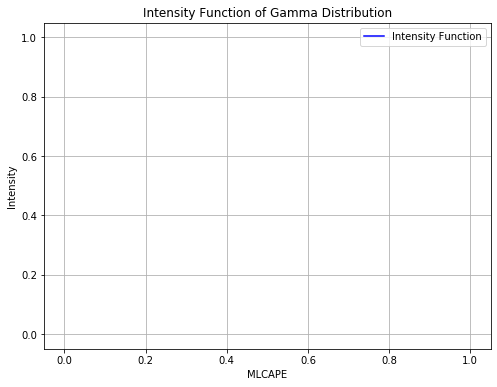

In [29]:
#calculate exceedance probability
extreme_df["exceedance_probability"] = gamma.sf(extreme_df["MLCAPE"], a, scale=b) #function in scripy

damage_values = extreme_df["MLCAPE"]
damage_transformed = extreme_df["transformed"]
exceedance_probability = extreme_df["exceedance_probability"]

# Calculate the intensity function
intensity = damage_transformed / exceedance_probability #from powerpoint

# Plotting the intensity function
plt.figure(figsize=(8, 6))
plt.plot(damage_values, intensity, label="Intensity Function", color='b')
plt.title("Intensity Function of Gamma Distribution")
plt.xlabel("MLCAPE")
plt.ylabel("Intensity")
plt.grid(True)
plt.legend()
plt.show()

In [30]:
exceedance_probability.to_csv("../extreme_value_outputs/exceedance_probability.csv",index = False)

In [26]:
%%bash
pwd


/home/jovyan/work/ESDA_AJJ54/ESDA_acv_project/df_full
